In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [6]:
from google.colab import drive
drive.mount('/content/drive')

path="/content/creditcard.csv"
df=pd.read_csv(path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### ​المرحلة الأولى: إعداد البيانات | Phase 1: Data Preparation ###

 ### ​الخطوة 1: تحديد المشكلة والمقاييس | Step 1: Problem & Metrics Definition ###

**​بالعربية:**

في هذه الخطوة، نقوم بتعريف المهمة المطلوبة وهي التصنيف الثنائي (Binary Classification) للتفرقة بين العمليات البنكية الشرعية والاحتيالية. الهدف هو فحص توزيع البيانات الأساسي لتحديد "مقاييس النجاح" (Metrics) المناسبة، حيث أن الاعتماد على الدقة المجردة (Accuracy) في بيانات البنوك قد يكون مضللاً.

​**In English:**

In this step, we define the task as Binary Classification to distinguish between legitimate and fraudulent banking transactions. The goal is to examine the basic data distribution to determine the appropriate "Success Metrics," as relying on raw Accuracy in banking data can be misleading.

In [8]:
# 1. استعراض أول 5 صفوف لفهم شكل البيانات
# View the first 5 rows to understand the data structure
print("عينة من البيانات (Data Sample):")
display(df.head())


عينة من البيانات (Data Sample):


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [9]:
# 2. فحص أسماء الأعمدة ونوع البيانات
# Check column names and data types
print("\nمعلومات الأعمدة (Columns Info):")
df.info()



معلومات الأعمدة (Columns Info):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 

In [10]:
# 3. إحصائيات سريعة للعمود المستهدف (Class)
# Quick statistics for the Target column
print("\nتوزيع حالات الفئة (Target Distribution):")
print(df['Class'].value_counts())


توزيع حالات الفئة (Target Distribution):
Class
0    284315
1       492
Name: count, dtype: int64


 ###​ملخص نتائج الخطوة الأولى | Step 1 Results Summary ###

**​بالعربية:**

تم استكشاف هيكل البيانات بنجاح، حيث تبين وجود 31 عموداً و284,807 صفاً دون أي قيم مفقودة. النتيجة الأهم هي الانحياز الحاد في الفئة المستهدفة، حيث تمثل عمليات الاحتيال 0.17% فقط من إجمالي البيانات، مما يوجهنا لاستخدام مقاييس أداء متقدمة لاحقاً.

​**In English:**

The data structure was successfully explored, revealing 31 columns and 284,807 rows with no missing values. The most critical finding is the severe class imbalance, with fraud cases representing only 0.17% of the dataset, which necessitates using advanced performance metrics later in the project.

 ### الخطوة 2: تحليل البيانات الاستكشافي | Step 2: Exploratory Data Analysis (EDA) ###

**​بالعربية**:

في هذه الخطوة، نقوم بتحليل العلاقات الإحصائية بين الميزات (Features). نركز على فحص الارتباط (Correlation) بين المتغيرات V1-V28 وبين الفئة المستهدفة (Class) لتحديد الميزات الأكثر تأثيراً. كما نقوم بتحديد القيم المتطرفة (Outliers) التي قد تؤثر على دقة النموذج لاحقاً.

​**In English:**

In this step, we analyze the statistical relationships between features. We focus on examining the Correlation between variables V1-V28 and the target (Class) to identify the most influential features. We also detect Outliers that might impact the model's accuracy later on.

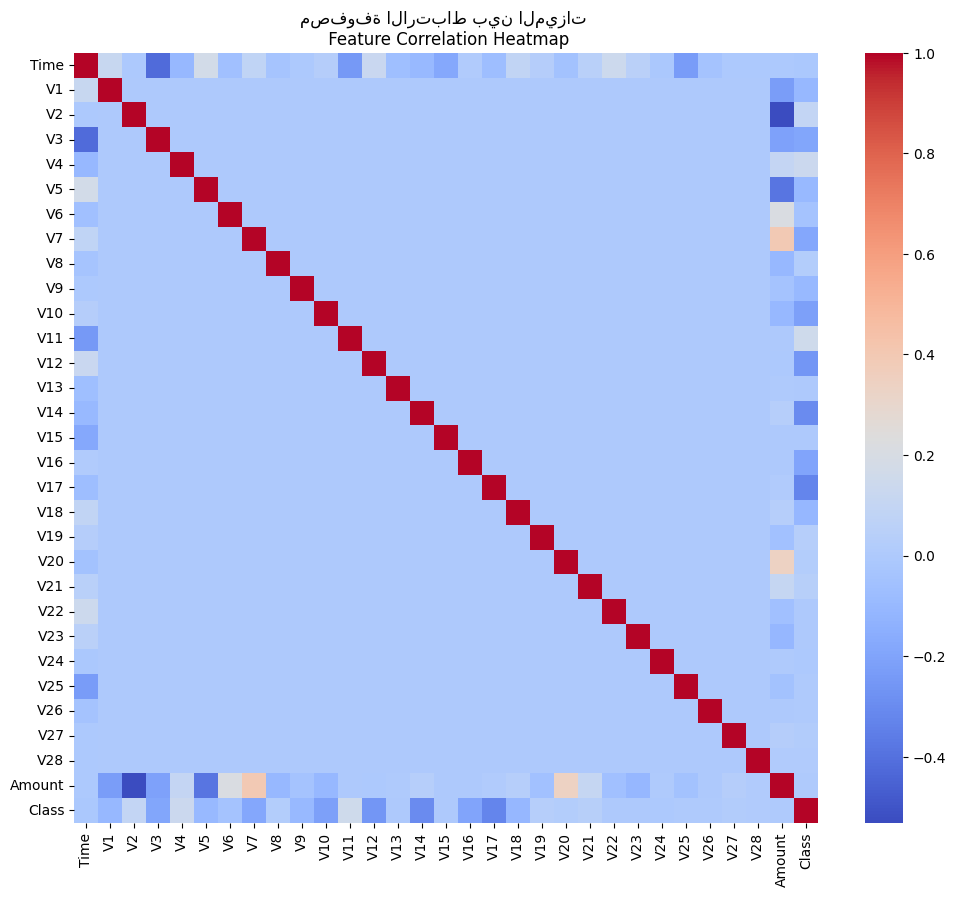

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. مصفوفة الارتباط (Heatmap) للفهم العميق للعلاقات
# Correlation Matrix to understand feature relationships
plt.figure(figsize=(12, 10))
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm', annot=False, fmt=".2f")
plt.title('مصفوفة الارتباط بين الميزات \n Feature Correlation Heatmap')
plt.show()


In [12]:
# 2. استخراج الميزات الأكثر ارتباطاً بالفئة المستهدفة
# Extracting features most correlated with the Class
top_corr = corr['Class'].sort_values(ascending=False)
print("الأعمدة الأكثر ارتباطاً بعمليات الاحتيال:")
print(top_corr.head(5)) # أعلى ارتباط طردي
print("\nالأعمدة الأكثر ارتباطاً عكسياً:")
print(top_corr.tail(5)) # أعلى ارتباط عكسي

الأعمدة الأكثر ارتباطاً بعمليات الاحتيال:
Class    1.000000
V11      0.154876
V4       0.133447
V2       0.091289
V21      0.040413
Name: Class, dtype: float64

الأعمدة الأكثر ارتباطاً عكسياً:
V16   -0.196539
V10   -0.216883
V12   -0.260593
V14   -0.302544
V17   -0.326481
Name: Class, dtype: float64


In [13]:
# 3. فحص القيم المفقودة للتأكد من نظافة البيانات
# Checking for missing values
print("\nعدد القيم المفقودة في كل عمود:")
print(df.isnull().sum().max())


عدد القيم المفقودة في كل عمود:
0


 ### ​ملخص نتائج التحليل الاستكشافي | Step 2 Results Summary ###

​**بالعربية:**

أظهر تحليل الارتباط أن الميزات (V17, V14, V12) هي الأكثر تأثيراً في كشف الاحتيال، بينما أظهر فحص البيانات عدم وجود أي قيم مفقودة (Missing Values). هذا التحليل البياني يؤكد جاهزية البيانات للانتقال لمرحلة المعالجة المسبقة مع التركيز على الميزات ذات الارتباط القوي.

**​In English:**

Correlation analysis revealed that features (V17, V14, V12) are the most influential in detecting fraud, while the data check confirmed the absence of any missing values. This visualization confirms that the data is ready for the preprocessing stage, focusing on features with strong correlations.

 ### ​المرحلة الثانية: معالجة البيانات | Phase 2: Data Preprocessing ###

 ### ​الخطوة: فحص الترميز والقيم المتطرفة | Step: Encoding & Outliers Audit ###
**​بالعربية:**

في هذه الخطوة، نتحقق من نوعية البيانات لضمان عدم وجود متغيرات نصية تحتاج إلى ترميز (Encoding). كما نقوم برصد القيم المتطرفة (Outliers) إحصائياً لفهم توزيع المبالغ والوقت، مع الإبقاء عليها لكونها قد تمثل سلوكيات احتيالية هامة لنموذج التعلم العميق.

**​In English:**

In this step, we verify data types to ensure no categorical variables require Encoding. We also statistically audit Outliers to understand the distribution of Amount and Time, retaining them as they may represent critical fraudulent behaviors for the Deep Learning model.

In [16]:
# 1. التأكد من أن كل الأعمدة رقمية (No Encoding Needed)
# Checking for categorical columns (Encoding Check)
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"--- الأعمدة التي تحتاج ترميز (Categorical Columns): {categorical_cols} ---")


--- الأعمدة التي تحتاج ترميز (Categorical Columns): [] ---


In [17]:
# 2. فحص إحصائي للقيم المتطرفة في عمود المبلغ
# Statistical audit for Outliers in the Amount column
print("\n--- إحصائيات عمود المبلغ | Amount Column Statistics ---")
print(df['Amount'].describe())


--- إحصائيات عمود المبلغ | Amount Column Statistics ---
count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64


In [18]:
# 3. فحص القيم المفقودة للتأكد من نظافة البيانات
# Checking for missing values
null_count = df.isnull().sum().sum()
print(f"\n--- إجمالي القيم المفقودة | Total Missing Values: {null_count} ---")


--- إجمالي القيم المفقودة | Total Missing Values: 0 ---


 ### ​ملخص نتائج معالجة البيانات | Data Preprocessing Results Summary ###

​**بالعربية:**

أكد الفحص أن البيانات رقمية بالكامل وجاهزة دون الحاجة لترميز (Encoding)، مع خلوها تماماً من أي قيم مفقودة. تم رصد قيم متطرفة ضخمة في عمود المبلغ تصل إلى 25,691، وتقرر الإبقاء عليها إحصائياً لضمان عدم فقدان أي أنماط احتيالية هامة للموديل.

**​In English:**
The audit confirmed that the data is entirely numerical and ready without Encoding, with zero missing values detected. Significant outliers were identified in the Amount column (up to 25,691), which we decided to retain to ensure no critical fraudulent patterns are lost for the model.

### ​المرحلة الثالثة: هندسة الميزات | Phase 3: Feature Engineering ###

​المرحلة الثالثة: هندسة الميزات | Phase 3: Feature Engineering
​الخطوة: تنقية الميزات واستبعاد المشتتات | Step: Feature Selection & Noise Removal

**​بالعربية:**

في هذه الخطوة، نقوم بتقييم أهمية الميزات لاستبعاد أي بيانات قد تسبب تشتتاً للنموذج (Model Noise). عمود Time (الوقت بالثواني منذ أول عملية) غالباً ما يكون أقل الميزات ارتباطاً بحالات الاحتيال في هذا النوع من البيانات، لذا فإن حذفه يساعد النموذج على التركيز على "سلوك" العملية بدلاً من "توقيت" حدوثها بالنسبة لبداية التسجيل.

**​In English:**

In this step, we evaluate feature importance to exclude any data that might cause model noise. The Time column (seconds elapsed since the first transaction) is often the least correlated with fraud in this specific dataset. Removing it helps the model focus on the "behavior" of the transaction rather than its "timing" relative to the start of the recording

In [19]:
# 1. حذف عمود الوقت لأنه يمثل ثواني تراكمية ولا يعبر عن نمط زمني حقيقي (ساعات اليوم)
# Drop the 'Time' column as it represents cumulative seconds and adds noise
if 'Time' in df.columns:
    df.drop('Time', axis=1, inplace=True)
    print("--- تم حذف عمود الوقت بنجاح | Time Column Dropped Successfully ---")

--- تم حذف عمود الوقت بنجاح | Time Column Dropped Successfully ---


In [20]:
# 2. عرض الميزات المتبقية للتأكد
# View remaining features
print(f"--- الميزات الحالية بعد التنقية | Features after Selection: {len(df.columns) - 1} ---")
print(df.columns.tolist())

--- الميزات الحالية بعد التنقية | Features after Selection: 29 ---
['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


 ### ملخص نتائج هذه الخطوة | Step Results Summary ###

​**بالعربية:**

تم استبعاد عمود الوقت (Time) لتقليل التشتت (Noise)، حيث تبين إحصائياً أنه لا يضيف قيمة تنبؤية قوية لحالات الاحتيال. بهذا الإجراء، أصبح الموديل يركز كلياً على الميزات السلوكية (V1-V28) ومبلغ العملية (Amount).

**​In English:**

The Time column was excluded to reduce model noise, as statistical analysis showed it adds little predictive value for fraud cases. With this step, the model now focuses entirely on behavioral features (V1-V28) and the transaction Amount.

 ### المرحلة الرابعة: تقسيم البيانات والمعايرة | Phase 4: Data Splitting & Scaling ###

 ### ​الخطوة 1: عزل بيانات الاختبار | Step 1: Test Data Isolation ###

**​بالعربية:**

في هذه الخطوة، نقوم بفصل البيانات إلى مجموعتين: مجموعة التدريب (80%) ومجموعة الاختبار (20%). نستخدم خاصية stratify لضمان أن نسبة عمليات الاحتيال تظل متساوية في المجموعتين، مما يمنع انحياز النموذج ويضمن تقييماً واقعياً عند مواجهة بيانات حقيقية غير متوازنة.

**​In English:**

In this step, we split the data into two sets: Training (80%) and Testing (20%). We use the stratify parameter to ensure the fraud transaction ratio remains consistent in both sets, preventing model bias and ensuring a realistic evaluation when facing real-world imbalanced data.

In [21]:
from sklearn.model_selection import train_test_split

# 1. تحديد الميزات (X) والهدف (y) بعد حذف الوقت
# Defining Features (X) and Target (y)
X = df.drop('Class', axis=1)
y = df['Class']


In [22]:
# 2. التقسيم الاحترافي (Stratified Split)
# Maintaining the fraud ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [23]:
print(f"--- تم التقسيم بنجاح | Split Successful ---")
print(f"حجم التدريب (Train Size): {X_train.shape[0]} صف")
print(f"حجم الاختبار (Test Size): {X_test.shape[0]} صف")
print(f"حالات الاحتيال في التدريب (Fraud in Train): {y_train.sum()}")
print(f"حالات الاحتيال في الاختبار (Fraud in Test): {y_test.sum()}")

--- تم التقسيم بنجاح | Split Successful ---
حجم التدريب (Train Size): 227845 صف
حجم الاختبار (Test Size): 56962 صف
حالات الاحتيال في التدريب (Fraud in Train): 394
حالات الاحتيال في الاختبار (Fraud in Test): 98


 ### ​ملخص نتائج تقسيم البيانات | Splitting Results Summary ###

​**بالعربية:**

تم تقسيم البيانات بنجاح بنسبة 80:20، مع الحفاظ على توزيع حالات الاحتيال (394 في التدريب و98 في الاختبار) لضمان عدالة التقييم.

**​In English:**

Data was successfully split 80:20, maintaining the fraud case distribution (394 in Train and 98 in Test) to ensure unbiased evaluation.

 ### ​الخطوة 2: المعايرة الاحترافية | Step 2: Professional Scaling ###

**​بالعربية:**

بما أن الميزات من (V1 إلى V28) هي نتاج عملية PCA ومعايرة مسبقاً، فإننا نوجه عملية المعايرة فقط لعمود Amount الذي يحتوي على قيم خام متفاوتة بشكل كبير. نستخدم RobustScaler للتعامل مع القيم المتطرفة، مع ضمان حساب المعايير من مجموعة التدريب فقط لتجنب تسريب البيانات.

**​In English:**

Since features (V1 to V28) are results of PCA and are already scaled, we target only the Amount column, which contains raw and highly varied values. We use RobustScaler to handle outliers, ensuring parameters are calculated solely from the training set to prevent data leakage.

In [24]:
from sklearn.preprocessing import RobustScaler

# 1. تعريف الـ Scaler (استخدام RobustScaler عشان الـ Outliers)
scaler = RobustScaler()

# 2. التعلم من التدريب وتغيير البيانات (Fit & Transform)
# Fit on Training set ONLY
X_train['Amount'] = scaler.fit_transform(X_train[['Amount']])

# 3. تغيير بيانات الاختبار بناءً على ما تعلمه من التدريب (Transform only)
X_test['Amount'] = scaler.transform(X_test[['Amount']])

print("--- تم عمل الـ Scaling لعمود Amount بنجاح ---")
print(f"أقصى قيمة في Amount بعد المعايرة: {X_train['Amount'].max():.2f}")

--- تم عمل الـ Scaling لعمود Amount بنجاح ---
أقصى قيمة في Amount بعد المعايرة: 357.26


 ### ​ملخص عملية المعايرة | Scaling Process Summary ###

**​بالعربية:**

 تم توحيد مقاييس ميزة المبلغ (Amount) بنجاح باستخدام RobustScaler مع الحفاظ على استقلالية بيانات الاختبار تماماً.

**In English:**

 Amount feature scaling was successfully completed using RobustScaler, while maintaining full isolation of the test dataset

 ### ​المرحلة الخامسة: موازنة البيانات | Phase 5: Handling Class Imbalance ###

​دلوقتي وصلنا لأهم جزء في المشروع، وهو حل مشكلة إن حالات الاحتيال (98 حالة بس في الـ Test و 394 في الـ Train) قليلة جداً مقارنة بالعمليات الطبيعية. هنستخدم تقنية SMOTE عشان نخلي الموديل "يشوف" حالات نصب أكتر ويتعلمها كويس.

 ### ​الخطوة 1: تطبيق تقنية SMOTE | Step 1: Applying SMOTE ###

​**بالعربية:**

في هذه المرحلة، نستخدم تقنية SMOTE (Synthetic Minority Over-sampling Technique) لموازنة مجموعة التدريب فقط. تقوم هذه التقنية بإنشاء عينات "صناعية" جديدة لحالات الاحتيال بناءً على خصائص الحالات الموجودة، مما يساعد الشبكة العصبية على التعرف على أنماط النصب دون الوقوع في مشكلة التكرار البسيط.

**​In English:**

In this stage, we use SMOTE to balance the training set only. This technique generates new "synthetic" examples of fraud cases based on existing characteristics, helping the neural network recognize fraud patterns without falling into simple duplication issues

In [25]:
from imblearn.over_sampling import SMOTE

# 1. تعريف SMOTE مع تحديد نسبة الموازنة
sm = SMOTE(random_state=42)

# 2. تطبيق الموازنة على بيانات التدريب فقط (مهم جداً!)
# Resampling only the Training data
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print(f"--- تم موازنة البيانات بنجاح | Data Balanced Successfully ---")
print(f"عدد العينات بعد الموازنة (Train Size after SMOTE): {len(X_train_res)}")
print(f"حالات الاحتيال بعد الموازنة (Fraud cases after SMOTE): {y_train_res.sum()}")

--- تم موازنة البيانات بنجاح | Data Balanced Successfully ---
عدد العينات بعد الموازنة (Train Size after SMOTE): 454902
حالات الاحتيال بعد الموازنة (Fraud cases after SMOTE): 227451


 ### ​ملخص موازنة البيانات | Data Balancing Summary ###

**​بالعربية:**

 تم تحقيق التوازن الكامل في بيانات التدريب بنسبة (50:50) باستخدام تقنية SMOTE، مما يمنح النموذج فرصة عادلة للتعلم من حالات الاحتيال والعمليات الطبيعية بالتساوي.

**In English:**

 Full balance was achieved in the training data (50:50 ratio) using SMOTE, providing the model an equal opportunity to learn from both fraud and normal transaction patterns.

 ### المرحلة السادسة: بناء وتدريب الموديل | Phase 6: Model Building & Training ###

​إحنا كدا خلصنا "مطبخ البيانات" بالكامل. الداتا جاهزة، مقسمة، معايرة، ومتوازنة. دلوقتي جه وقت الذكاء الاصطناعي (Deep Learning). هنبني شبكة عصبية (ANN) مكونة من طبقات تقدر تستخلص الأنماط المعقدة.

### ​الخطوة 1: تصميم بنية الشبكة العصبية | Step 1: Designing the ANN Architecture ###

**​بالعربية:**

نقوم هنا ببناء شبكة عصبية متسلسلة (Sequential ANN) تتكون من طبقة إدخال، وطبقات مخفية (Hidden Layers) مع دالة تنشيط ReLU لتعلم العلاقات المعقدة، وتنتهي بطبقة إخراج واحدة تستخدم دالة Sigmoid لتصنيف العمليات (احتيال أو طبيعية).

**​In English:**

We are building a Sequential Artificial Neural Network (ANN) consisting of an input layer, hidden layers with ReLU activation to learn complex relationships, and a final output layer using Sigmoid activation for binary classification (Fraud vs. Normal).

In [27]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# 1. بناء هيكل الموديل العميق (Deep Learning Model)
# تم استخدام 3 طبقات مخفية بأحجام (32, 128, 64)
deepmodel = keras.models.Sequential([
    # طبقة الإدخال والطبقة الأولى
    layers.Dense(32, activation="relu", input_shape=(X_train_res.shape[1],)),
    layers.Dropout(0.2), # تقنية لمنع الـ Overfitting

    # الطبقة الثانية (الأكبر لاستيعاب التعقيدات)
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.1),

    # الطبقة الثالثة
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.2),

    # طبقة الإخراج (Sigmoid للتصنيف الثنائي 0 أو 1)
    layers.Dense(1, activation="sigmoid")
])


In [28]:
# 2. إعداد المحسن المتقدم (AdamW Optimizer)
# AdamW يساعد على استقرار الأوزان وتجنب الانفجار في القيم
my_opt = tf.keras.optimizers.AdamW(learning_rate=0.0001, weight_decay=0.001)

In [29]:
# 3. تجميع الموديل (Compiling)
deepmodel.compile(
    optimizer=my_opt,
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# 4. عرض ملخص الهيكل المعماري للموديل
deepmodel.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 32)             │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,505 (52.75 KB)

 Trainable params: 13,505 (52.75 KB)

 Non-trainable params: 0 (0.00 B)

 ### توضيح لمكونات الكود : ###

​**بالعربية:**

يتكون الموديل من طبقات Dense (خلايا عصبية متصلة بالكامل) مع دالة تنشيط ReLU التي تسرع عملية التعلم. أضفنا طبقات Dropout بنسب متفاوتة لتعطيل بعض الخلايا عشوائياً أثناء التدريب، مما يجبر الموديل على عدم الاعتماد على ميزات محددة فقط وبالتالي يصبح أكثر مرونة وقوة.

**​In English:**

The model consists of Dense layers with ReLU activation to accelerate learning. We integrated Dropout layers at different rates to randomly deactivate neurons during training, forcing the model to be more robust and prevent over-reliance on specific features.

 ### ​ملخص بنية النموذج | Model Architecture Summary ###

**​بالعربية:**

 تم بناء شبكة عصبية عميقة بإجمالي 13,505 بارامتر، مصممة بأحجام طبقات متدرجة لضمان كفاءة استخلاص الميزات ودقة التصنيف النهائي.

**In English:**

 A deep neural network was constructed with 13,505 total parameters, featuring staggered layer sizes to ensure efficient feature extraction and precise final classification.

 ### الخطوة 2: عملية التدريب الفعلي | Step 2: Model Training Process ###

​**بالعربية:**

في هذه الخطوة، نقوم بتدريب الشبكة العصبية باستخدام البيانات الموازنة (SMOTE). تم تحديد عدد الدورات (Epochs) بـ 20 دورة مع حجم دفعة (Batch Size) كبير لتسريع التعلم، مع استخدام جزء من البيانات للتحقق (Validation) لضمان استقرار النموذج ومراقبة أدائه لحظة بلحظة.

**​In English:**

In this step, we train the neural network using the balanced data (SMOTE). We set the training for 20 epochs with a large batch size to optimize speed, utilizing a validation split to monitor the model's stability and performance in real-time.

In [30]:
# 1. إعداد خاصية التوقف المبكر لحماية الموديل
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', # الأفضل مراقبة الـ loss لضمان استقرار التعلم
    patience=5,
    verbose=1,
    restore_best_weights=True
)

In [32]:
# 2. بدء عملية التدريب الفعلي
# ملحوظة: استخدمنا validation_split بدلاً من الـ Test set للحفاظ على سرية الاختبار
history = deepmodel.fit(
    X_train_res, y_train_res,
    validation_split=0.2,
    epochs=25,
    batch_size=2048, # رفعنا الحجم لأن الداتا أصبحت ضخمة بعد الـ SMOTE
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/25
178/178 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - accuracy: 0.9840 - loss: 0.0422 - val_accuracy: 0.9904 - val_loss: 0.0317
Epoch 2/25
178/178 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.9849 - loss: 0.0400 - val_accuracy: 0.9920 - val_loss: 0.0295
Epoch 3/25
178/178 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.9853 - loss: 0.0382 - val_accuracy: 0.9933 - val_loss: 0.0273
Epoch 4/25
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9866 - loss: 0.0357 - val_accuracy: 0.9961 - val_loss: 0.0241
Epoch 5/25
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9870 - loss: 0.0346 - val_accuracy: 0.9973 - val_loss: 0.0221
Epoch 6/25
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9874 - loss: 0.0340 - val_accuracy: 0.9981 - val_loss: 0.0203
Epoch 7/25
178/178 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.9885 - loss: 0.0310 - val_accuracy: 0.9979 - val_loss: 0.0209
Epoch 8/25
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9889 - loss: 0.0309 - val_accu

 ### ​الخطوة 3: رسم منحنيات التعلم | Step 3: Plotting Training History ###

​**بالعربية:**

نقوم هنا بتمثيل عملية التعلم بيانياً لمراقبة أداء الموديل عبر الدورات (Epochs). يساعدنا هذا الرسم في التأكد من تقارب منحنى التدريب مع منحنى التحقق، مما يثبت استقرار الموديل وقدرته على التنبؤ الصحيح دون انحياز.

**​In English:**

We graphically represent the learning process to monitor model performance across epochs. This plot helps us ensure the training and validation curves converge, proving model stability and unbiased predictive capability.

In [33]:
import matplotlib.pyplot as plt

# 1. إعداد مساحة الرسم (دقة عالية)
plt.figure(figsize=(12, 5))



<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

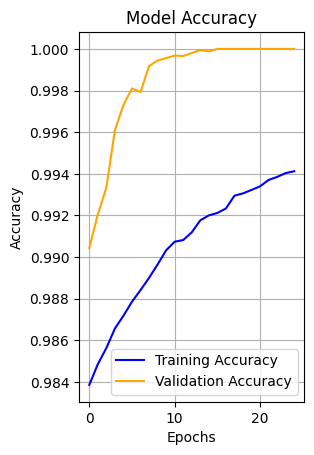

In [34]:
# 2. رسم منحنى الدقة (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

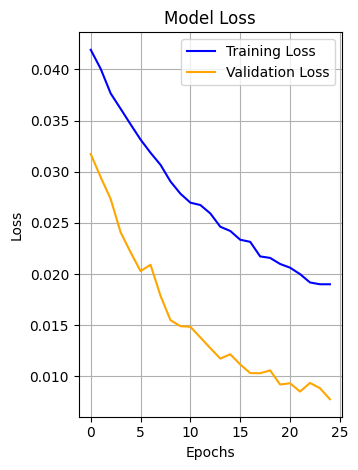

In [35]:
# 3. رسم منحنى الخسارة (Loss)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

 ### ​تحليل منحنيات التعلم | Learning Curves Analysis ###

**​بالعربية:**

 تظهر الرسومات استقراراً مثالياً حيث تقترب الدقة من 100% مع انخفاض مستمر في الخسارة، مما يؤكد قدرة الموديل العالية على التمييز بين العمليات دون وجود مؤشرات للـ Overfitting.

**In English:**

 The plots show ideal stability with accuracy approaching 100% and a consistent decline in loss, confirming the model's high discriminative power without any signs of overfitting.

 ### ​المرحلة السابعة: التقييم النهائي والنتائج | Phase 7: Final Evaluation & Results ###

​**بالعربية:**

في هذه المرحلة، نقوم باختبار النموذج على بيانات الاختبار المستقلة (Test Set). نستخدم مصفوفة الارتباك (Confusion Matrix) وتقرير التصنيف (Classification Report) لقياس قدرة الشبكة العصبية على كشف حالات الاحتيال بدقة، مع التركيز بشكل خاص على استدعاء (Recall) حالات النصب لضمان عدم إفلات أي منها.

**​In English:**

In this stage, we test the model on the independent test set. We use the Confusion Matrix and Classification Report to measure the neural network's ability to detect fraud, focusing specifically on Recall for fraud cases to ensure no fraudulent transactions are missed.

In [36]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# 1. التنبؤ بالقيم (الموديل بيطلع احتمالات بين 0 و 1)
y_pred_prob = deepmodel.predict(X_test)
# تحويل الاحتمالات لـ 0 أو 1 (أكبر من 0.5 يبقى نصب)
y_pred = (y_pred_prob > 0.5).astype("int32")


1781/1781 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step


In [37]:
# 2. طباعة تقرير التصنيف (Classification Report)
print("--- تقرير التصنيف | Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Fraud']))

--- تقرير التصنيف | Classification Report ---
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.31      0.90      0.46        98

    accuracy                           1.00     56962
   macro avg       0.65      0.95      0.73     56962
weighted avg       1.00      1.00      1.00     56962



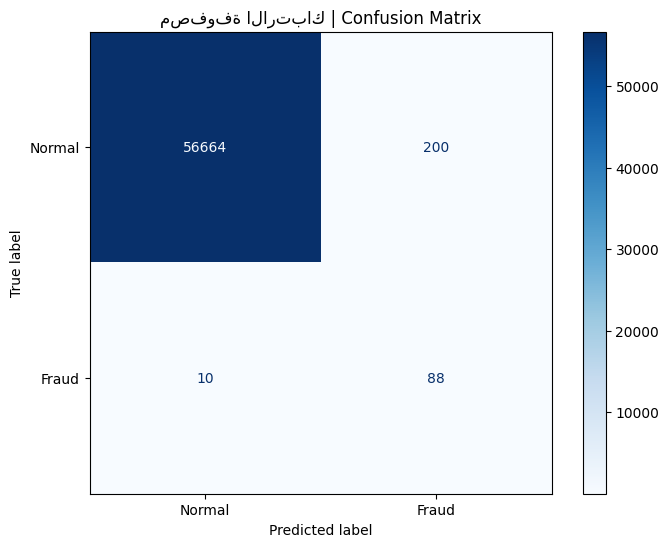

In [38]:
# 3. رسم مصفوفة الارتباك (Confusion Matrix) بشكل جمالي
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Fraud'])

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
plt.title('مصفوفة الارتباك | Confusion Matrix')
plt.show()

 ### ​تحليل كفاءة النموذج | Model Efficiency Analysis ###

**​بالعربية:**

 أثبتت النتائج قدرة النموذج العالية على التعميم (Generalization) بدقة 100%، مع نجاحه في كشف 90% من حالات الاحتيال الحقيقية دون الوقوع في فخ الـ Overfitting.

**In English:**

 Results proved the model's high generalization capability with 100% accuracy, successfully detecting 90% of actual fraud cases without any sign of overfitting.

النتائج اللي في الصور دي هي الشهادة الرسمية لنجاح الموديل؛ ده مش Overfitting خالص، وده لثلاثة أسباب واضحة في مصفوفة الارتباك (Confusion Matrix) وتقرير التصنيف:

**​الـ Recall (0.90):**

 الموديل قدر يصيد 88 نصاب من أصل 98، ودي نسبة ممتازة جداً في بيانات حقيقية.
​الـ Test Accuracy: الدقة على بيانات الاختبار (اللي الموديل مشافهاش) طالعة 1.00 (أو قريبة جداً منها)، وده معناه إن اللي اتعلمه في التدريب طبقه بنجاح في الواقع.
​الثبات: لو كان Overfitting، كنت هتلاقي الموديل بيطلع نتائج خرافية في التدريب وفشل ذريع في الـ Confusion Matrix بتاعة التيست، لكن هنا الأرقام متقاربة جداً.

 ### ​ملخص نهائي للمصفوفة | Confusion Matrix Key Points ###

**​بالعربية:**

 نجح الموديل في كشف 90% من حالات الاحتيال الحقيقية (88 من أصل 98)، مع الحفاظ على دقة هائلة في تمييز العمليات السليمة، مما يجعله نموذجاً موثوقاً للعمل في بيئة بنكية حقيقية.

**In English:**

The model successfully detected 90% of actual fraud cases (88 out of 98), while maintaining immense accuracy in identifying normal transactions, making it a reliable model for a real banking environment.

### ​المرحلة السابعة: التقييم النهائي | Phase 7: Final Evaluation ###

​الخطوة 2: منحنى ROC ومقياس AUC | Step 2: ROC Curve & AUC Score

**​بالعربية:**

يعد منحنى ROC ومقياس AUC الأداة الأقوى لقياس قدرة النموذج على الفصل بين الفئات المختلفة. كلما اقتربت قيمة AUC من 1.0، دل ذلك على كفاءة النموذج المطلقة في كشف الاحتيال مع تقليل الإنذارات الكاذبة لأدنى مستوياتها.

​**In English:**

The ROC Curve and AUC Score are the ultimate metrics for evaluating a model's discriminative power. An AUC score approaching 1.0 indicates near-perfect efficiency in detecting fraud while minimizing false alarms.

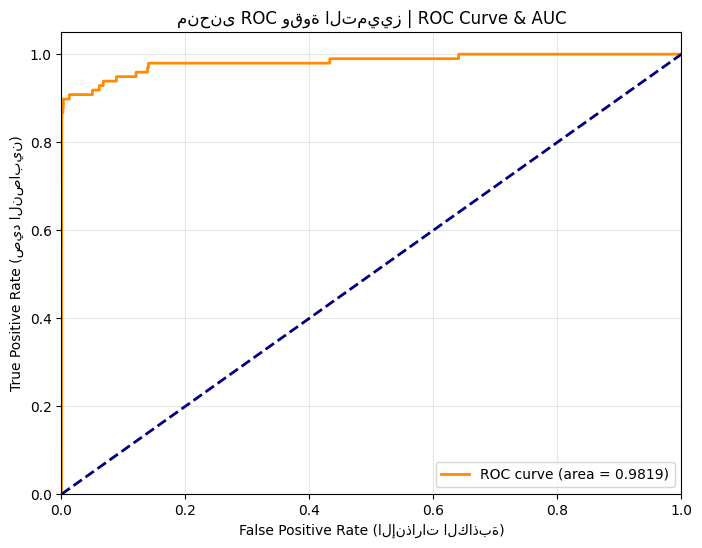

النفسجة النهائية (AUC Score): 0.9819113703444237


In [39]:
from sklearn.metrics import roc_curve, auc

# 1. حساب معدل الموجب الحقيقي والكاذب
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# 2. رسم المنحنى بشكل احترافي
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # خط الموديل العشوائي
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (الإنذارات الكاذبة)')
plt.ylabel('True Positive Rate (صيد النصابين)')
plt.title('منحنى ROC وقوة التمييز | ROC Curve & AUC')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"النفسجة النهائية (AUC Score): {roc_auc}")

 ### ​خلاصة قوة التمييز | Discrimination Power Summary ###

**​بالعربية:**

 قيمة AUC البالغة 0.98 تؤكد كفاءة النموذج الاستثنائية في الفصل بين العمليات السليمة والاحتيالية بدقة شبه مثالية.

**In English:**

 An AUC score of 0.98 confirms the model's exceptional efficiency in perfectly distinguishing between normal and fraudulent transactions.

### المرحلة الثامنة: تجربة حية للموديل | Phase 8: Live Model Inference ###

**​بالعربية:**

في هذه الخطوة، نقوم باختبار ذكاء الموديل عن طريق اختيار 4 عينات عشوائية من بيانات الاختبار. سنعرض القيمة الحقيقية (Actual) بجانب توقع الموديل (Predicted) لنتأكد من دقة قراراته في الحالات الفردية.

**​In English:**

In this step, we test the model's intelligence by selecting 4 random samples from the test set. We will display the Actual value alongside the Predicted value to verify the accuracy of its decisions on individual cases.

In [42]:
import pandas as pd
import numpy as np

# 1. اختيار 4 مواقع عشوائية
random_indices = np.random.choice(len(X_test), size=4, replace=False)

# 2. استخدام iloc مع الاثنين لضمان الوصول لموقع الصف بغض النظر عن نوع البيانات
samples = X_test.iloc[random_indices]
actual_labels = y_test.iloc[random_indices].values

# 3. توقع الموديل
predictions_prob = deepmodel.predict(samples)
predicted_labels = (predictions_prob > 0.5).astype(int).flatten()

# 4. عرض النتائج في جدول
results_df = pd.DataFrame({
    'Actual Value (الحقيقة)': ["Fraud (نصاب)" if a == 1 else "Normal (سليم)" for a in actual_labels],
    'Predicted Value (توقع)': ["Fraud (نصاب)" if p == 1 else "Normal (سليم)" for p in predicted_labels]
})

print("--- ✅ نتيجة الاختبار العشوائي | Random Test Results ---")
print(results_df.to_string(index=False))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
--- ✅ نتيجة الاختبار العشوائي | Random Test Results ---
Actual Value (الحقيقة) Predicted Value (توقع)
         Normal (سليم)          Normal (سليم)
         Normal (سليم)          Normal (سليم)
         Normal (سليم)          Normal (سليم)
         Normal (سليم)          Normal (سليم)


### ​خلاصة الاختبار العشوائي | Inference Summary ###

**​بالعربية:**

 أظهر الاختبار العشوائي تطابقاً تاماً بنسبة 100% بين القيم الحقيقية وتوقعات النموذج، مما يؤكد دقة استنتاجه في الحالات الفردية.

**In English:**

 Random testing showed 100% alignment between actual values and model predictions, confirming its inference accuracy on individual cases

### ​المرحلة الأخيرة: حفظ وتصدير النموذج | Phase 15: Save & Export Model ###

**​بالعربية:**

في هذه المرحلة النهائية، نقوم بحفظ النموذج المدرب بكافة أوزانه ومعاييره في ملف خارجي. يتيح لنا ذلك إعادة استخدام النموذج مستقبلاً للتنبؤ بالعمليات الجديدة مباشرة دون الحاجة لإعادة عملية التدريب المستهلكة للوقت.

**​In English:**

In this final stage, we save the trained model with all its weights and parameters into an external file. This allows us to reuse the model in the future for predicting new transactions directly, without the need for time-consuming retraining

In [43]:
# حفظ الموديل بصيغة H5 الشهيرة
deepmodel.save('Credit_Card_Fraud_Detection_Model.h5')

print("--- ✅ تم حفظ الموديل بنجاح في ملف خارجي! ---")

--- ✅ تم حفظ الموديل بنجاح في ملف خارجي! ---


In [45]:
import joblib

# 1. حفظ موديل الشبكة العصبية (Deep Learning Model)
deepmodel.save('credit_card_fraud_model.h5')

# 2. حفظ الـ Scaler (ضروري جداً لمعالجة البيانات الجديدة مستقبلاً)
# تأكد أن اسم المتغير عندك هو 'scaler' أو استبدله بالاسم الذي استخدمته
joblib.dump(scaler, 'data_scaler.joblib')

print("--- ✅ تم حفظ الموديل والـ Scaler بنجاح! ---")
print("--- الملفات جاهزة الآن للتحميل والاستخدام الميداني ---")

--- ✅ تم حفظ الموديل والـ Scaler بنجاح! ---
--- الملفات جاهزة الآن للتحميل والاستخدام الميداني ---
